In [1]:
import math
import os
import random
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

random.seed(42)
torch.manual_seed(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")


dataset = load_dataset("wikitext", "wikitext-2-raw-v1")


Device: mps


## Разведочный анализ данных WikiText-2:

Просмотр примеров текстов, статистики по строкам и предложениям, средние длины и распределения длин.

In [2]:
# Смотрим на структуру
print("Тип датасета:", type(dataset))
print("Поля датасета:", dataset.column_names)
print("Всего строк в датасете:", len(dataset))

Тип датасета: <class 'datasets.dataset_dict.DatasetDict'>
Поля датасета: {'test': ['text'], 'train': ['text'], 'validation': ['text']}
Всего строк в датасете: 3


In [3]:
# Примеры текстов
# Берём первые 10 непустых строк для ознакомления

non_empty = [line for line in dataset["train"]["text"] if line.strip()]

print("Примеры непустых строк (первые 10):")

for i, line in enumerate(non_empty[:10], 1):
    print(f"\n[{i}] {line[:300]}{'...' if len(line) > 300 else ''}")

Примеры непустых строк (первые 10):

[1]  = Valkyria Chronicles III = 


[2]  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in Janu...

[3]  The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Character designer Raita Hon...

[4]  It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an expanded edition in November of that year . It was also adapted into manga and an original video animation series . Due to low sales of Valky...



In [4]:
# Базовая статистика по строкам датасета

all_lines = dataset["train"]["text"]

# Пустые vs непустые строки
empty_lines = [l for l in all_lines if not l.strip()]
non_empty_lines = [l for l in all_lines if l.strip()]

print(f"Всего строк:          {len(all_lines):>8}")
print(f"Пустых строк:         {len(empty_lines):>8}")
print(f"Непустых строк:       {len(non_empty_lines):>8}")

Всего строк:             36718
Пустых строк:            12951
Непустых строк:          23767


In [ ]:
# Статистика по словам (на непустых строках)

word_counts = [len(line.split()) for line in non_empty_lines]

print("Статистика по числу слов в строке:")
print(f"Всего слов в датасете: {sum(word_counts):>10,}")
print(f"Среднее:               {np.mean(word_counts):>10.2f}")
print(f"Медиана:               {np.median(word_counts):>10.2f}")
print(f"Станд. отклонение:     {np.std(word_counts):>10.2f}")
print(f"Минимум:               {np.min(word_counts):>10}")
print(f"Максимум:              {np.max(word_counts):>10}")
print(f"5-й перцентиль:        {np.percentile(word_counts, 5):>10.2f}")
print(f"95-й перцентиль:       {np.percentile(word_counts, 95):>10.2f}")

Статистика по числу слов в строке:
  Всего слов в датасете:  2,051,910
  Среднее:                    86.33
  Медиана:                    74.00
  Станд. отклонение:          81.63
  Минимум:                        1
  Максимум:                     699
  5-й перцентиль:              5.00
  95-й перцентиль:           237.00


In [ ]:
# Разбиваем непустые строки на предложения
# Предложение = фрагмент, оканчивающийся на '.', '!' или '?'


def split_sentences(text):
    """
    Функция разбиения текста на предложения по знакам препинания.
    """
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    # убираем совсем пустые фрагменты
    return [s for s in sentences if s.strip()]


all_sentences = []
for line in non_empty_lines:
    all_sentences.extend(split_sentences(line))

print(f"Всего предложений (приблизительно): {len(all_sentences):,}")

# Длины предложений в словах
sent_word_counts = [len(s.split()) for s in all_sentences]

print("\nСтатистика по числу слов в предложении:")
print(f"Среднее:               {np.mean(sent_word_counts):>10.2f}")
print(f"Медиана:               {np.median(sent_word_counts):>10.2f}")
print(f"Станд. отклонение:     {np.std(sent_word_counts):>10.2f}")
print(f"5-й перцентиль:        {np.percentile(sent_word_counts, 5):>10.2f}")
print(f"95-й перцентиль:       {np.percentile(sent_word_counts, 95):>10.2f}")

Всего предложений (приблизительно): 88,275

Статистика по числу слов в предложении:
  Среднее:                    23.24
  Медиана:                    22.00
  Станд. отклонение:          13.52
  5-й перцентиль:              5.00
  95-й перцентиль:            47.00


In [7]:
# Топ-20 самых частых слов

# Простая токенизация: lowercase + только буквенно-цифровые символы
all_words = []
for line in non_empty_lines:
    tokens = re.findall(r"[a-zA-Z]+", line.lower())
    all_words.extend(tokens)

word_freq = Counter(all_words)
top20 = word_freq.most_common(20)

print("Топ-20 самых частых слов:")
print(f"{'Слово':<15} {'Частота':>10}")
print("-" * 27)
for word, freq in top20:
    print(f"{word:<15} {freq:>10,}")

print(f"\nРазмер словаря (уникальных слов): {len(word_freq):,}")

Топ-20 самых частых слов:
Слово              Частота
---------------------------
the                130,771
of                  57,032
and                 50,738
in                  45,027
to                  39,524
a                   36,834
was                 21,008
s                   16,375
on                  15,158
as                  15,063
that                14,351
for                 13,797
with                13,012
by                  12,718
is                  11,692
it                   9,279
from                 9,229
at                   9,071
his                  9,020
he                   8,718

Размер словаря (уникальных слов): 61,884


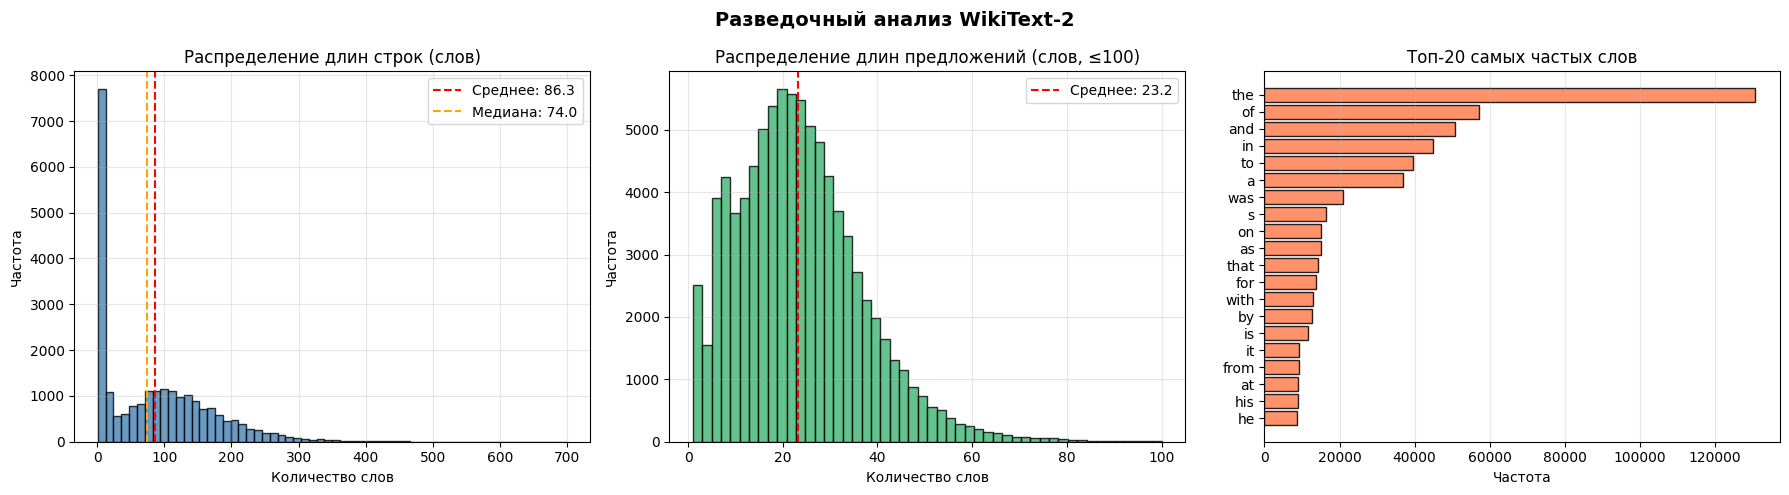

In [8]:
# Визуализации

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Разведочный анализ WikiText-2", fontsize=14, fontweight="bold")

# 1) Распределение длин строк (в словах)
ax = axes[0]
ax.hist(word_counts, bins=60, edgecolor="black", color="steelblue", alpha=0.8)
ax.axvline(
    np.mean(word_counts),
    color="red",
    linestyle="--",
    label=f"Среднее: {np.mean(word_counts):.1f}",
)
ax.axvline(
    np.median(word_counts),
    color="orange",
    linestyle="--",
    label=f"Медиана: {np.median(word_counts):.1f}",
)
ax.set_title("Распределение длин строк (слов)")
ax.set_xlabel("Количество слов")
ax.set_ylabel("Частота")
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Распределение длин предложений (в словах)
ax = axes[1]
clipped = [c for c in sent_word_counts if c <= 100]
ax.hist(clipped, bins=50, edgecolor="black", color="mediumseagreen", alpha=0.8)
ax.axvline(
    np.mean(sent_word_counts),
    color="red",
    linestyle="--",
    label=f"Среднее: {np.mean(sent_word_counts):.1f}",
)
ax.set_title("Распределение длин предложений (слов, ≤100)")
ax.set_xlabel("Количество слов")
ax.set_ylabel("Частота")
ax.legend()
ax.grid(True, alpha=0.3)

# 3) Топ-20 слов (столбчатая диаграмма)
ax = axes[2]
words_plot = [w for w, _ in top20]
counts_plot = [c for _, c in top20]
bars = ax.barh(
    words_plot[::-1],
    counts_plot[::-1],
    color="coral",
    edgecolor="black",
    alpha=0.85,
)
ax.set_title("Топ-20 самых частых слов")
ax.set_xlabel("Частота")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

In [9]:
# Итоговая сводка

print("Итоговая сводка:")
print(f"Непустых строк:              {len(non_empty_lines):>8,}")
print(f"Всего слов:                  {sum(word_counts):>8,}")
print(f"Уникальных слов:             {len(word_freq):>8,}")
print(f"Всего предложений (approx.): {len(all_sentences):>8,}")
print(f"Средняя длина строки:        {np.mean(word_counts):>8.1f} слов")
print(f"Средняя длина предложения:   {np.mean(sent_word_counts):>8.1f} слов")

Итоговая сводка:
Непустых строк:                23,767
Всего слов:                  2,051,910
Уникальных слов:               61,884
Всего предложений (approx.):   88,275
Средняя длина строки:            86.3 слов
Средняя длина предложения:       23.2 слов


### Краткий вывод по EDA

WikiText-2 содержит много пустых строк и служебных заголовков, поэтому перед обучением используются только непустые и достаточно длинные строки. Распределение длин строк и предложений неравномерное: встречаются как короткие фрагменты, так и длинные абзацы. Это обосновывает разбиение текстов на окна фиксированной длины `seq_len=32` и замену редких слов на `<UNK>`.

In [10]:
# Подготовка данных для обучения

train_raw = dataset["train"]["text"]
val_raw = dataset["validation"]["text"]


def clean_string(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


seq_len = 32

train_texts = [
    clean_string(line) for line in train_raw if len(line.split()) > seq_len
]
val_texts = [
    clean_string(line) for line in val_raw if len(line.split()) > seq_len
]

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MIN_FREQ = 3

word_freq = Counter()
for line in train_texts:
    word_freq.update(line.split())

vocab_words = sorted(w for w, c in word_freq.items() if c >= MIN_FREQ)

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in vocab_words:
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f"Vocab size: {VOCAB_SIZE}")


def encode(text):
    return [word2idx.get(token, word2idx[UNK_TOKEN]) for token in text.split()]


class LMDataset(Dataset):
    def __init__(self, texts, seq_len=32):
        self.samples = []
        for line in texts:
            token_ids = encode(line)
            if len(token_ids) < seq_len:
                continue
            for i in range(0, len(token_ids) - seq_len + 1, seq_len):
                window = token_ids[i : i + seq_len]
                x = window[:-1]
                y = window[1:]
                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return (
            torch.tensor(x, dtype=torch.long),
            torch.tensor(y, dtype=torch.long),
        )


train_dataset = LMDataset(train_texts, seq_len=seq_len)
val_dataset = LMDataset(val_texts, seq_len=seq_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(
    f"Train dataset size: {len(train_dataset)}, Val dataset size: {len(val_dataset)}"
)

Vocab size: 28824
Train dataset size: 46147, Val dataset size: 4837


In [11]:
# Универсальный класс модели: LSTM или GRU
# Отличие GRU от LSTM — тип рекуррентного слоя.
# Вынесем его в параметр rnn_type, чтобы не дублировать код.


class RNNLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=256,
        num_layers=2,
        dropout=0.3,
        rnn_type="LSTM",  # "LSTM" или "GRU"
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.rnn_type = rnn_type

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        rnn_cls = {"LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.dropout(self.embedding(x))
        out, hidden = self.rnn(emb, hidden)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits, hidden


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# гиперпараметры — одинаковые для обеих моделей
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3
LR = 0.001
N_EPOCHS = 10
CLIP = 5.0

lstm_model = RNNLanguageModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, rnn_type="LSTM"
).to(device)

gru_model = RNNLanguageModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, rnn_type="GRU"
).to(device)

print(f"Параметров в LSTM: {count_parameters(lstm_model):,}")
print(f"Параметров в GRU:  {count_parameters(gru_model):,}")

Параметров в LSTM: 12,018,840
Параметров в GRU:  11,788,440


In [12]:
# Вспомогательные функции обучения и оценки

criterion = nn.CrossEntropyLoss(ignore_index=0)


def train_epoch(model, loader, optimizer, clip):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in tqdm(loader, leave=False):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_batch)
        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            y_batch.reshape(-1),
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits, _ = model(x_batch)
            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                y_batch.reshape(-1),
            )
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    return avg_loss, math.exp(avg_loss)


def run_training(model, rnn_type):
    """
    Обучает модель и возвращает историю метрик и время на эпоху.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    train_losses, val_losses, val_ppls, epoch_times = [], [], [], []

    print(f"\n{'=' * 55}")
    print(f"  Обучение {rnn_type}")
    print(f"{'=' * 55}")

    for epoch in range(N_EPOCHS):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, CLIP)
        val_loss, val_ppl = evaluate(model, val_loader)
        elapsed = time.time() - t0

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_ppls.append(val_ppl)
        epoch_times.append(elapsed)

        print(
            f"Epoch {epoch + 1:>2} | "
            f"Train Loss: {train_loss:.3f} | "
            f"Val Loss: {val_loss:.3f} | "
            f"Val PPL: {val_ppl:.2f} | "
            f"Time: {elapsed:.1f}s"
        )

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_ppls": val_ppls,
        "epoch_times": epoch_times,
    }


## Этап 2. Обучение LSTM

Обучаем LSTM-модель с gradient clipping, выводим loss и perplexity на каждой эпохе, строим графики.


  Обучение LSTM


Epoch  1 | Train Loss: 7.459 | Val Loss: 6.871 | Val PPL: 963.85 | Time: 75.3s


Epoch  2 | Train Loss: 7.078 | Val Loss: 6.651 | Val PPL: 773.62 | Time: 79.2s


Epoch  3 | Train Loss: 6.870 | Val Loss: 6.501 | Val PPL: 666.02 | Time: 102.3s


Epoch  4 | Train Loss: 6.699 | Val Loss: 6.383 | Val PPL: 591.84 | Time: 111.7s


...

Epoch  6 | Train Loss: 6.438 | Val Loss: 6.221 | Val PPL: 503.32 | Time: 114.8s


Epoch  7 | Train Loss: 6.338 | Val Loss: 6.168 | Val PPL: 477.15 | Time: 112.9s


Epoch  8 | Train Loss: 6.252 | Val Loss: 6.133 | Val PPL: 460.64 | Time: 117.0s


Epoch  9 | Train Loss: 6.177 | Val Loss: 6.097 | Val PPL: 444.43 | Time: 117.6s


Epoch 10 | Train Loss: 6.109 | Val Loss: 6.077 | Val PPL: 435.92 | Time: 115.6s


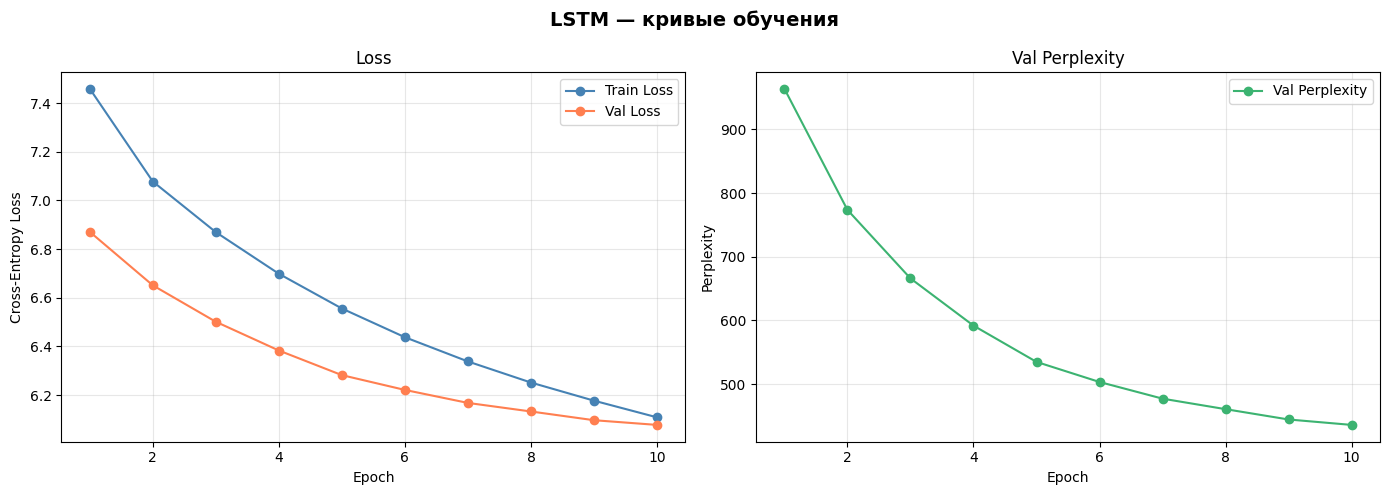


Лучший Val PPL LSTM: 435.92 (epoch 10)


In [13]:
# Обучение LSTM

lstm_model = RNNLanguageModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, rnn_type="LSTM"
).to(device)

lstm_history = run_training(lstm_model, "LSTM")


# График обучения LSTM
epochs_range = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM — кривые обучения", fontsize=14, fontweight="bold")

axes[0].plot(
    epochs_range,
    lstm_history["train_losses"],
    marker="o",
    label="Train Loss",
    color="steelblue",
)
axes[0].plot(
    epochs_range,
    lstm_history["val_losses"],
    marker="o",
    label="Val Loss",
    color="coral",
)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    epochs_range,
    lstm_history["val_ppls"],
    marker="o",
    label="Val Perplexity",
    color="mediumseagreen",
)
axes[1].set_title("Val Perplexity")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"\nЛучший Val PPL LSTM: {min(lstm_history['val_ppls']):.2f} (epoch {lstm_history['val_ppls'].index(min(lstm_history['val_ppls'])) + 1})"
)


## Этап 3. Эксперимент: GRU vs LSTM

Обучаем GRU с теми же гиперпараметрами и сравниваем с LSTM по perplexity, числу параметров и скорости.

In [14]:
# Обучение GRU

gru_model = RNNLanguageModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, rnn_type="GRU"
).to(device)

gru_history = run_training(gru_model, "GRU")



  Обучение GRU


Epoch  1 | Train Loss: 7.473 | Val Loss: 6.959 | Val PPL: 1052.40 | Time: 123.5s


Epoch  2 | Train Loss: 7.126 | Val Loss: 6.609 | Val PPL: 741.43 | Time: 119.8s


Epoch  3 | Train Loss: 6.773 | Val Loss: 6.308 | Val PPL: 549.11 | Time: 142.6s


Epoch  4 | Train Loss: 6.488 | Val Loss: 6.139 | Val PPL: 463.50 | Time: 143.6s


...

Epoch  6 | Train Loss: 6.140 | Val Loss: 5.981 | Val PPL: 395.84 | Time: 131.7s


Epoch  7 | Train Loss: 6.019 | Val Loss: 5.938 | Val PPL: 378.99 | Time: 125.1s


Epoch  8 | Train Loss: 5.915 | Val Loss: 5.906 | Val PPL: 367.29 | Time: 126.4s


Epoch  9 | Train Loss: 5.827 | Val Loss: 5.892 | Val PPL: 362.26 | Time: 134.0s


Epoch 10 | Train Loss: 5.747 | Val Loss: 5.873 | Val PPL: 355.32 | Time: 143.0s


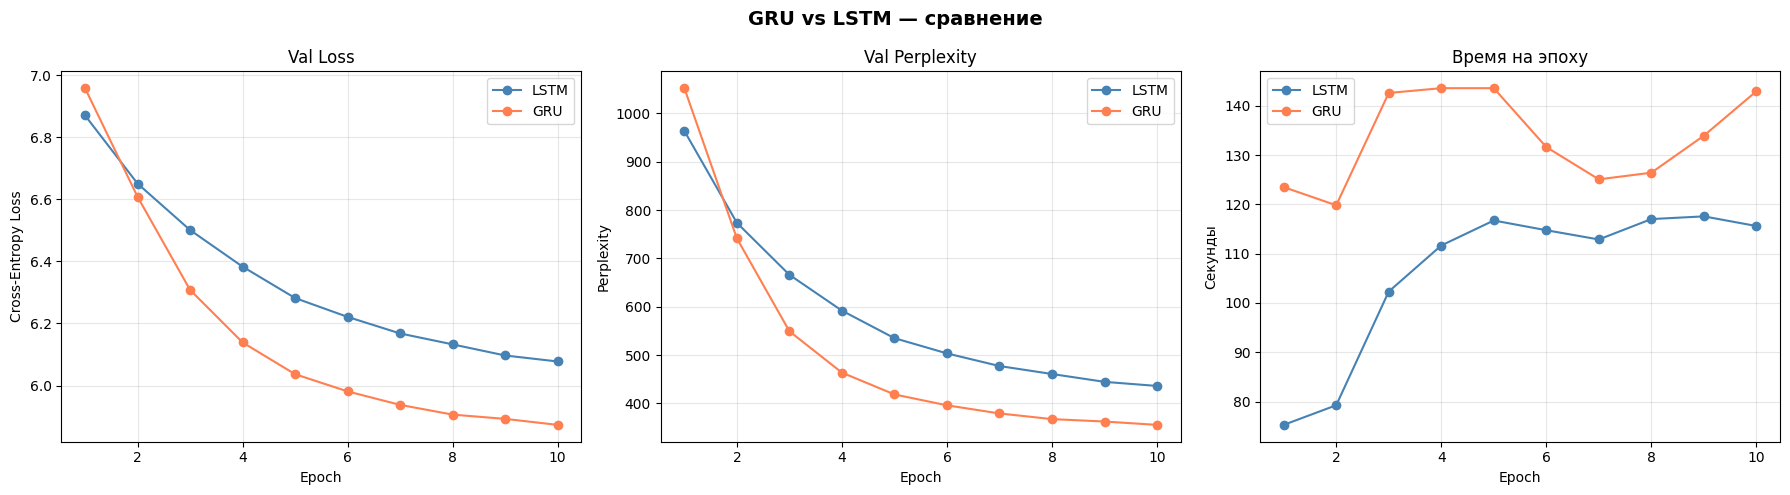


Метрика                                LSTM          GRU
-------------------------------------------------------
Параметров                       12,018,840   11,788,440
Лучший Val PPL                       435.92       355.32
Среднее время эпохи (с)               106.3        133.3


In [15]:
# Сравнение результатов

epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GRU vs LSTM — сравнение", fontsize=14, fontweight="bold")

# Val Loss
axes[0].plot(
    epochs,
    lstm_history["val_losses"],
    marker="o",
    label="LSTM",
    color="steelblue",
)
axes[0].plot(
    epochs, gru_history["val_losses"], marker="o", label="GRU", color="coral"
)
axes[0].set_title("Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val Perplexity
axes[1].plot(
    epochs,
    lstm_history["val_ppls"],
    marker="o",
    label="LSTM",
    color="steelblue",
)
axes[1].plot(
    epochs, gru_history["val_ppls"], marker="o", label="GRU", color="coral"
)
axes[1].set_title("Val Perplexity")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Время на эпоху
axes[2].plot(
    epochs,
    lstm_history["epoch_times"],
    marker="o",
    label="LSTM",
    color="steelblue",
)
axes[2].plot(
    epochs, gru_history["epoch_times"], marker="o", label="GRU", color="coral"
)
axes[2].set_title("Время на эпоху")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Секунды")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Итоговая таблица сравнения
lstm_params = count_parameters(lstm_model)
gru_params = count_parameters(gru_model)
lstm_best_ppl = min(lstm_history["val_ppls"])
gru_best_ppl = min(gru_history["val_ppls"])
lstm_avg_time = np.mean(lstm_history["epoch_times"])
gru_avg_time = np.mean(gru_history["epoch_times"])

print(f"\n{'Метрика':<30} {'LSTM':>12} {'GRU':>12}")
print("-" * 55)
print(f"{'Параметров':<30} {lstm_params:>12,} {gru_params:>12,}")
print(f"{'Лучший Val PPL':<30} {lstm_best_ppl:>12.2f} {gru_best_ppl:>12.2f}")
print(
    f"{'Среднее время эпохи (с)':<30} {lstm_avg_time:>12.1f} {gru_avg_time:>12.1f}"
)

In [16]:
# Сохранение весов лучшей модели
# По результатам обучения GRU показала лучший Val PPL, поэтому сохраняем её

os.makedirs("weights", exist_ok=True)

# Сохраняем веса GRU (лучшая модель по Val PPL)
torch.save(gru_model.state_dict(), "weights/gru_best.pt")

# Сохраняем веса LSTM для сравнения
torch.save(lstm_model.state_dict(), "weights/lstm_best.pt")

print("Веса моделей сохранены:")
print("weights/gru_best.pt")
print("weights/lstm_best.pt")

# Проверка загрузки весов
test_model = RNNLanguageModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, rnn_type="GRU"
).to(device)
test_model.load_state_dict(
    torch.load("weights/gru_best.pt", map_location=device)
)
test_model.eval()
print("Проверка загрузки весов GRU: OK")


Веса моделей сохранены:
weights/gru_best.pt
weights/lstm_best.pt
Проверка загрузки весов GRU: OK


In [17]:
# Загрузка токенизатора и модели
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

In [18]:
# Примеры генерации distilgpt2

# Для качественных примеров не используем одновременно max_length и
# max_new_tokens в model.generate(). max_length оставляем только на этапе
# токенизации входного промпта, а длину продолжения ограничиваем max_new_tokens.
# Также добавляем параметры против повторов, чтобы модель не зацикливалась на
# одной и той же фразе.

model.to(device)
model.eval()


def generate_distilgpt2(prompt, max_new_tokens=40):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=60,
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_k=50,
            top_p=0.95,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# промпты из тематики WikiText-2
prompts = [
    "The history of the Roman Empire began",
    "Scientists have recently discovered that",
    "The theory of relativity states that",
    "During the Second World War",
    "The first computer was invented",
]

print("Примеры генерации distilgpt2:")
print("=" * 60)

for prompt in prompts:
    generated_text = generate_distilgpt2(prompt, max_new_tokens=40)
    print(f"Промпт : {prompt}")
    print(f"Ответ  : {generated_text}")
    print("-" * 60)


Примеры генерации distilgpt2:
Промпт : The history of the Roman Empire began
Ответ  : The history of the Roman Empire began in 1607 when a young prince and an exile named Tausius Vianus was murdered at Mount Sinai by his uncle, Alexander II (the son-in law), who had already been appointed
------------------------------------------------------------
Промпт : Scientists have recently discovered that
Ответ  : Scientists have recently discovered that a new type of gene might lead to cancer.
The genes responsible for the formation and maintenance of tumours on human skin make them difficult to recognise from their surroundings, according Toiletto Marrero
------------------------------------------------------------
Промпт : The theory of relativity states that
Ответ  : The theory of relativity states that the universe is a part of an object, but rather than as one.
A person's body consists only in some parts (or pieces) or other objects on its own; and it cannot be
--------------------------

In [19]:
# Сравнение моделей: test set и distilgpt2

# Тестовый датасет для LSTM/GRU: используем тот же word-level preprocessing,
# что и при обучении, чтобы словарь и индексы совпадали.
test_raw = dataset["test"]["text"]
test_texts = [
    clean_string(line) for line in test_raw if len(line.split()) > seq_len
]

test_dataset = LMDataset(test_texts, seq_len=seq_len)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print(f"Test dataset size: {len(test_dataset)}")

# Test PPL для LSTM и GRU
lstm_test_loss, lstm_test_ppl = evaluate(lstm_model, test_loader)
gru_test_loss, gru_test_ppl = evaluate(gru_model, test_loader)


def compute_perplexity_gpt2(texts, gpt2_model, gpt2_tokenizer, max_len=512):
    """
    Функция вычтсления perplexity causal LM в токенах собственного токенизатора модели.

    Важно:
    - distilgpt2 использует BPE-токены, поэтому PPL не сравнивается напрямую
      с word-level PPL LSTM/GRU.
    - outputs.loss усредняется по предсказываемым токенам; для causal LM их
      примерно n - 1, поэтому взвешиваем loss на число предсказанных токенов.
    """
    gpt2_model.to(device)
    gpt2_model.eval()
    gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

    total_nll = 0.0
    total_tokens = 0

    with torch.no_grad():
        for text in tqdm(texts, desc="distilgpt2 PPL", leave=False):
            if not text.strip():
                continue
            input_ids = gpt2_tokenizer(text, return_tensors="pt")[
                "input_ids"
            ].to(device)
            input_ids = input_ids[:, :max_len]
            n = input_ids.size(1)
            if n < 2:
                continue

            outputs = gpt2_model(input_ids, labels=input_ids)
            predicted_tokens = n - 1
            total_nll += outputs.loss.item() * predicted_tokens
            total_tokens += predicted_tokens

    return math.exp(total_nll / total_tokens)


# Для distilgpt2 передаём сырые тексты: у модели собственный BPE-токенизатор.
val_raw_nonempty = [t for t in val_raw if t.strip()]
test_raw_nonempty = [t for t in test_raw if t.strip()]

gpt2_val_ppl = compute_perplexity_gpt2(val_raw_nonempty, model, tokenizer)
gpt2_test_ppl = compute_perplexity_gpt2(test_raw_nonempty, model, tokenizer)

# Итоговая таблица
lstm_params = count_parameters(lstm_model)
gru_params = count_parameters(gru_model)
gpt2_params = sum(p.numel() for p in model.parameters())

lstm_val_ppl = min(lstm_history["val_ppls"])
gru_val_ppl = min(gru_history["val_ppls"])

lstm_avg_time = np.mean(lstm_history["epoch_times"])
gru_avg_time = np.mean(gru_history["epoch_times"])

print(
    f"\n{'Модель':<12} {'Параметров':>12} {'Val PPL':>10} {'Test PPL':>10} {'Время/эпоху':>13}"
)
print("-" * 62)
print(
    f"{'LSTM':<12} {lstm_params:>12,} {lstm_val_ppl:>10.2f} {lstm_test_ppl:>10.2f} {lstm_avg_time:>12.1f}s"
)
print(
    f"{'GRU':<12} {gru_params:>12,} {gru_val_ppl:>10.2f} {gru_test_ppl:>10.2f} {gru_avg_time:>12.1f}s"
)
print(
    f"{'distilgpt2':<12} {gpt2_params:>12,} {gpt2_val_ppl:>10.2f} {gpt2_test_ppl:>10.2f} {'—':>12}"
)
print()
print(
    "* distilgpt2 PPL считается в BPE-токенах; прямое численное сравнение "
    "с word-level LSTM/GRU некорректно."
)


Test dataset size: 5434


distilgpt2 PPL:   0%|          | 0/2461 [00:00<?, ?it/s]`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
                                                                   


Модель         Параметров    Val PPL   Test PPL   Время/эпоху
--------------------------------------------------------------
LSTM           12,018,840     435.92     417.03        106.3s
GRU            11,788,440     355.32     335.65        133.3s
distilgpt2     81,912,576      75.73      74.42            —

* distilgpt2 PPL считается в BPE-токенах; прямое численное сравнение с word-level LSTM/GRU некорректно.


In [20]:
# Примеры предсказаний на одинаковых контекстах


def predict_next_rnn(rnn_model, context_str, top_k=5):
    """
    Возвращает топ-k следующих слов по пословному словарю.
    Берём последние seq_len-1 токенов контекста.
    """
    rnn_model.eval()
    tokens = clean_string(context_str).split()
    ids = [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens]
    ids = ids[-(seq_len - 1) :]
    x = torch.tensor([ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits, _ = rnn_model(x)
        probs = torch.softmax(logits[0, -1, :], dim=-1)
        top_probs, top_ids = torch.topk(probs, top_k)

    return [
        (idx2word.get(i.item(), UNK_TOKEN), p.item())
        for i, p in zip(top_ids, top_probs)
    ]


def predict_next_gpt2(prompt, top_k=5):
    """
    Возвращает топ-k следующих токенов по версии distilgpt2.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    model.to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits[0, -1, :], dim=-1)
        top_probs, top_ids = torch.topk(probs, top_k)

    return [
        (tokenizer.decode(i.item()).strip(), p.item())
        for i, p in zip(top_ids, top_probs)
    ]


# контексты для сравнения
contexts = [
    "the history of the roman empire",
    "scientists have recently discovered that",
    "the theory of relativity states",
    "during the second world",
    "the president of the united states",
    "the movie was directed by",
    "he was born in the city of",
]

TOP_K = 5

print("Топ-5 предсказаний следующего токена:")

for ctx in contexts:
    lstm_preds = predict_next_rnn(lstm_model, ctx, TOP_K)
    gru_preds = predict_next_rnn(gru_model, ctx, TOP_K)
    gpt2_preds = predict_next_gpt2(ctx, TOP_K)

    print(f'\nКонтекст: "{ctx}"')
    print(f"  {'LSTM':<25} {'GRU':<25} {'distilgpt2'}")
    print(f"  {'-' * 23}   {'-' * 23}   {'-' * 23}")
    for i in range(TOP_K):
        l_word, l_prob = lstm_preds[i]
        g_word, g_prob = gru_preds[i]
        d_word, d_prob = gpt2_preds[i]
        print(
            f"  {l_word:<15} ({l_prob:.3f})   "
            f"{g_word:<15} ({g_prob:.3f})   "
            f"{d_word:<15} ({d_prob:.3f})"
        )


Топ-5 предсказаний следующего токена:

Контекст: "the history of the roman empire"
  LSTM                      GRU                       distilgpt2
  -----------------------   -----------------------   -----------------------
  of              (0.087)   and             (0.076)   .               (0.231)
  and             (0.086)   of              (0.071)   ,               (0.146)
  in              (0.058)   in              (0.066)   and             (0.085)
  was             (0.048)   was             (0.065)   is              (0.064)
  the             (0.041)   the             (0.058)   in              (0.055)

Контекст: "scientists have recently discovered that"
  LSTM                      GRU                       distilgpt2
  -----------------------   -----------------------   -----------------------
  the             (0.213)   the             (0.317)   the             (0.149)
  it              (0.068)   it              (0.075)   a               (0.045)
  a               (0.046)   the

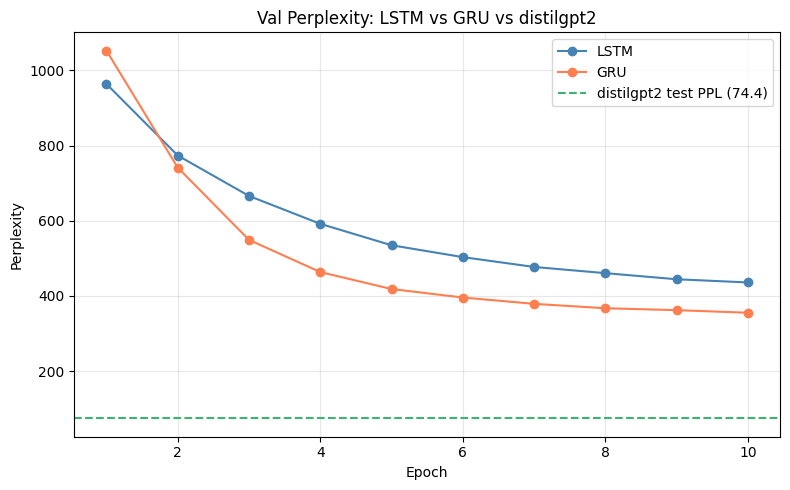

In [21]:
# Визуализация: Val PPL по эпохам + линия distilgpt2

epochs = range(1, N_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    lstm_history["val_ppls"],
    marker="o",
    label="LSTM",
    color="steelblue",
)
plt.plot(
    epochs, gru_history["val_ppls"], marker="o", label="GRU", color="coral"
)
plt.axhline(
    gpt2_test_ppl,
    linestyle="--",
    color="mediumseagreen",
    label=f"distilgpt2 test PPL ({gpt2_test_ppl:.1f})",
)
plt.title("Val Perplexity: LSTM vs GRU vs distilgpt2")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Выводы

## 1. Сравнение LSTM и GRU

| Модель | Параметров | Val PPL | Test PPL | Среднее время эпохи |
|---|---:|---:|---:|---:|
| LSTM | 12,018,840 | 435.92 | 417.03 | 106.3 s |
| GRU | 11,788,440 | 355.32 | 335.65 | 133.3 s |

GRU заметно превзошла LSTM по качеству: val PPL ниже примерно на **18.5%**, test PPL ниже примерно на **19.5%**.
Разница в числе параметров небольшая (~1.9%), так как основную долю занимают embedding-слой
и выходной линейный слой на весь словарь.

В данном запуске GRU обучалась медленнее LSTM (~25% на эпоху). Это может зависеть от устройства
и реализации, поэтому при переносе на другое железо стоит заново замерить скорость.

**Вывод:** GRU предпочтительнее LSTM для задачи языкового моделирования на WikiText-2 —
она даёт лучшую perplexity при сопоставимом числе параметров.

## 2. Сравнение с `distilgpt2`

| Модель | Параметров | Val PPL | Test PPL |
|---|---:|---:|---:|
| LSTM | 12,018,840 | 435.92 | 417.03 |
| GRU | 11,788,440 | 355.32 | 335.65 |
| distilgpt2 | 81,912,576 | 75.73 | 74.42 |

`distilgpt2` показывает существенно меньшую perplexity, но это значение в BPE-токенах,
поэтому прямое численное сравнение некорректно.

Качественные примеры подтверждают преимущество трансформера: он чаще выдаёт контекстно
осмысленные следующие токены. Например, на контексте `"the theory of relativity states"`
distilgpt2 уверенно предсказывает `that` (вероятность 0.637), тогда как LSTM даёт лишь 0.120.
На контексте `"during the second world"` все три модели правильно предсказывают `war`,
но distilgpt2 делает это с вероятностью 0.957 против 0.260 у LSTM и 0.653 у GRU.

Главная причина преимущества `distilgpt2` — предобучение на большом корпусе и более мощная
transformer-архитектура с механизмом attention. LSTM и GRU обучались с нуля только на WikiText-2.

## 3. Рекомендации для продакт-менеджера

| Сценарий | Рекомендация |
|---|---|
| Максимальное качество, есть GPU / облако | `distilgpt2` или более крупная предобученная transformer-модель |
| Быстрый MVP без обучения с нуля | `distilgpt2` — уже предобучена, работает «из коробки» |
| Компактная модель, обученная с нуля | GRU: лучшая perplexity при меньшем числе параметров |
| Скорость обучения приоритетнее качества | LSTM: в этом запуске обучалась на ~25% быстрее GRU |
| Кастомный словарь, узкий домен | LSTM/GRU с дообучением на доменных данных |

## 4. Итоговый вывод

Для продуктового решения следует выбрать предобученный трансформер (`distilgpt2` или более современную
модель) — он даёт более качественные и связные предсказания без обучения с нуля.

Среди моделей, обученных с нуля на WikiText-2, лидирует **GRU**: она превзошла LSTM
по Val PPL на ~18.5% и по Test PPL на ~19.5% при незначительно меньшем числе параметров.

LSTM уступила GRU по качеству, однако обучалась примерно на 25% быстрее — это актуально
при ограниченном вычислительном бюджете.
